# HUDF Analysis — f105w, f125w, f160w
Author: Cielo Vera


## Step 5: Load the f105w image


In [19]:
from astropy.io import fits
import numpy as np

file105 = '/Users/cielovera/Downloads/hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits'
data105 = fits.getdata(file105, ext=0).astype('float32')

print(f"f105w image shape: {data105.shape}")


f105w image shape: (3600, 3600)


## Step 6: Background subtraction and source extraction


In [21]:
import sep

# Background estimation
bkg = sep.Background(data105)
data_sub = data105 - bkg

# Source extraction
objects = sep.extract(data_sub, thresh=1.5)
print(f"Number of sources found: {len(objects)}")


Number of sources found: 12


In [22]:
## Step 6: Histogram of fluxes


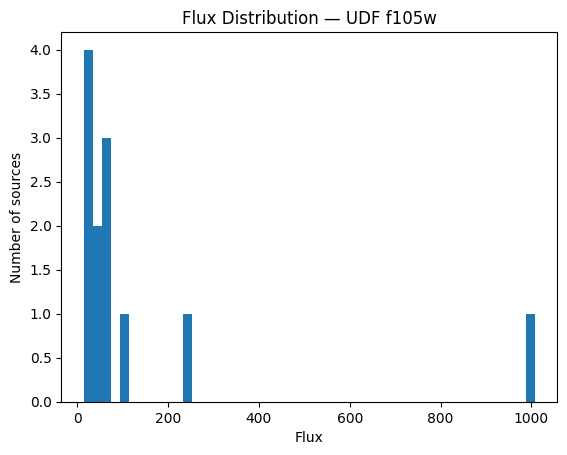

<Figure size 640x480 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt

fluxes = objects['flux']

plt.hist(fluxes, bins=50)
plt.xlabel("Flux")
plt.ylabel("Number of sources")
plt.title("Flux Distribution — UDF f105w")
plt.show()

plt.savefig("f105w_flux_hist.png")


## Step 7: Compute mean, median, standard deviation and find the largest outlier


In [24]:
mean_flux = np.mean(fluxes)
median_flux = np.median(fluxes)
std_flux = np.std(fluxes)

largest_flux = np.max(fluxes)
idx = np.argmax(fluxes)
largest_obj = objects[idx]

sigma_away = (largest_flux - mean_flux) / std_flux
x_out, y_out = largest_obj['x'], largest_obj['y']

print(f"Mean: {mean_flux}, Median: {median_flux}, Std: {std_flux}")
print(f"Largest flux: {largest_flux} at ({x_out:.1f}, {y_out:.1f}), {sigma_away:.2f} σ away from mean")


Mean: 144.293799161911, Median: 58.13601493835449, Std: 266.7041572331315
Largest flux: 1007.1278686523438 at (1914.2, 1134.5), 3.24 σ away from mean


## Step 8: Create a 3-color RGB image using f105w, f125w, and f160w


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-78.45885..6456.058].


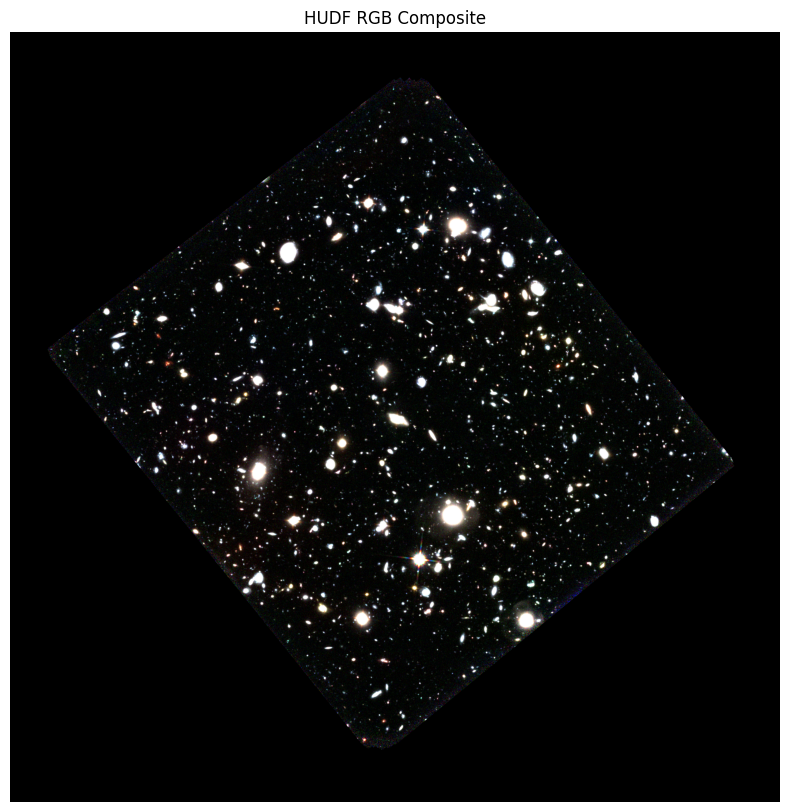

<Figure size 640x480 with 0 Axes>

In [25]:
# Load all three bands
file125 = '/Users/cielovera/Downloads/hlsp_hudf12_hst_wfc3ir_udfmain_f125w_v1.0_drz.fits'
file160 = '/Users/cielovera/Downloads/hlsp_hudf12_hst_wfc3ir_udfmain_f160w_v1.0_drz.fits'

img125 = fits.getdata(file125, ext=0).astype(np.float32)
img160 = fits.getdata(file160, ext=0).astype(np.float32)
img105 = data105  # already loaded

# Normalize each image
def normalize(image):
    return image / np.percentile(image, 99)

r = normalize(img160)  # Red
g = normalize(img125)  # Green
b = normalize(img105)  # Blue

# Stack channels
rgb = np.dstack([r, g, b])

# Display the RGB image
plt.figure(figsize=(10,10))
plt.imshow(rgb, origin='lower')
plt.axis('off')
plt.title("HUDF RGB Composite")
plt.show()

# Save the RGB image
plt.savefig("UDF_RGB.png", dpi=200, bbox_inches='tight')
